In [ ]:
print("E-Commerce Customer & Sales Analytics Project")

E-Commerce Customer & Sales Analytics Project


In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 150

customers = [
    "Aarav Sharma", "Priya Patil", "Rahul Joshi", "Sneha Kulkarni",
    "Aditya Deshmukh", "Neha Shah", "Rohan More", "Pooja Pawar",
    "Sanket Jadhav", "Kajal Patil", "Amit Chavan", "Snehal More",
    "Vishal Shinde", "Anjali Thakur", "Akshay Pawar", "Nikita Joshi",
    "Pranav Patil", "Riya Deshmukh", "Kunal More", "Mansi Shah"
]

cities = ["Pune", "Nashik", "Mumbai", "Nagpur", "Aurangabad"]

categories = ["Electronics", "Accessories", "Home Appliances", "Stationery"]

products = {
    "Laptop": ("Electronics", 55000),
    "Mobile": ("Electronics", 25000),
    "Headphones": ("Accessories", 2000),
    "Keyboard": ("Accessories", 1500),
    "Mouse": ("Accessories", 800),
    "Monitor": ("Electronics", 12000),
    "Printer": ("Electronics", 15000),
    "Webcam": ("Accessories", 3000),
    "Tablet": ("Electronics", 22000),
    "Speaker": ("Electronics", 5000),
    "Mixer": ("Home Appliances", 4500),
    "Iron": ("Home Appliances", 1800),
    "Notebook": ("Stationery", 120),
    "Calculator": ("Stationery", 500)
}

product_names = list(products.keys())

data = []

for i in range(1, n + 1):
    customer = np.random.choice(customers)
    product = np.random.choice(product_names)
    category, unit_price = products[product]
    quantity = np.random.randint(1, 5)

    data.append([
        f"ORD{i:03d}",
        pd.Timestamp("2026-01-01") + pd.Timedelta(days=np.random.randint(0, 180)),
        f"CUST{customers.index(customer)+1:03d}",
        customer,
        np.random.choice(cities),
        category,
        product,
        quantity,
        unit_price,
        quantity * unit_price
    ])

df = pd.DataFrame(data, columns=[
    "Order_ID",
    "Order_Date",
    "Customer_ID",
    "Customer_Name",
    "City",
    "Category",
    "Product",
    "Quantity",
    "Unit_Price",
    "Sales"
])

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,City,Category,Product,Quantity,Unit_Price,Sales
0,ORD001,2026-01-15,CUST007,Rohan More,Mumbai,Accessories,Keyboard,1,1500,1500
1,ORD002,2026-04-13,CUST008,Pooja Pawar,Nashik,Stationery,Notebook,1,120,120
2,ORD003,2026-03-29,CUST019,Kunal More,Aurangabad,Electronics,Printer,3,15000,45000
3,ORD004,2026-05-11,CUST004,Sneha Kulkarni,Aurangabad,Accessories,Webcam,4,3000,12000
4,ORD005,2026-06-07,CUST002,Priya Patil,Nashik,Accessories,Webcam,4,3000,12000


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (150, 10)

Column Names:
['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'City', 'Category', 'Product', 'Quantity', 'Unit_Price', 'Sales']

Data Types:
Order_ID                 object
Order_Date       datetime64[ns]
Customer_ID              object
Customer_Name            object
City                     object
Category                 object
Product                  object
Quantity                  int64
Unit_Price                int64
Sales                     int64
dtype: object

Missing Values:
Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Name    0
City             0
Category         0
Product          0
Quantity         0
Unit_Price       0
Sales            0
dtype: int64

Duplicate Rows:
0


In [ ]:
df.describe()

,Order_Date,Quantity,Unit_Price,Sales
count,150,150.000000,150.000000,150.000000
mean,2026-04-03 03:12:00,2.580000,10777.733333,29240.666667
min,2026-01-01 00:00:00,1.000000,120.000000,120.000000
25%,2026-02-20 06:00:00,1.000000,1500.000000,2100.000000
50%,2026-04-04 00:00:00,3.000000,3000.000000,8000.000000
75%,2026-05-20 00:00:00,4.000000,15000.000000,36000.000000
max,2026-06-28 00:00:00,4.000000,55000.000000,220000.000000
std,NaN,1.183046,15644.753142,50100.581165


In [ ]:
# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Remove rows with missing values
df = df.dropna()

# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Check result
print("\nDataset shape after cleaning:", df.shape)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nDuplicate rows after cleaning:", df.duplicated().sum())

Missing values before cleaning:
Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Name    0
City             0
Category         0
Product          0
Quantity         0
Unit_Price       0
Sales            0
dtype: int64

Dataset shape after cleaning: (150, 10)

Missing values after cleaning:
Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Name    0
City             0
Category         0
Product          0
Quantity         0
Unit_Price       0
Sales            0
dtype: int64

Duplicate rows after cleaning: 0


In [ ]:
print("Total Orders:", df["Order_ID"].nunique())
print("Total Customers:", df["Customer_ID"].nunique())
print("Total Sales: ₹", df["Sales"].sum())
print("Total Quantity:", df["Quantity"].sum())
print("Average Order Value: ₹", round(df["Sales"].mean(), 2))
print("Average Quantity per Order:", round(df["Quantity"].mean(), 2))

Total Orders: 150
Total Customers: 20
Total Sales: ₹ 4386100
Total Quantity: 387
Average Order Value: ₹ 29240.67
Average Quantity per Order: 2.58


In [ ]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(category_sales)

Category
Electronics        4042000
Accessories         211800
Home Appliances     115200
Stationery           17100
Name: Sales, dtype: int64


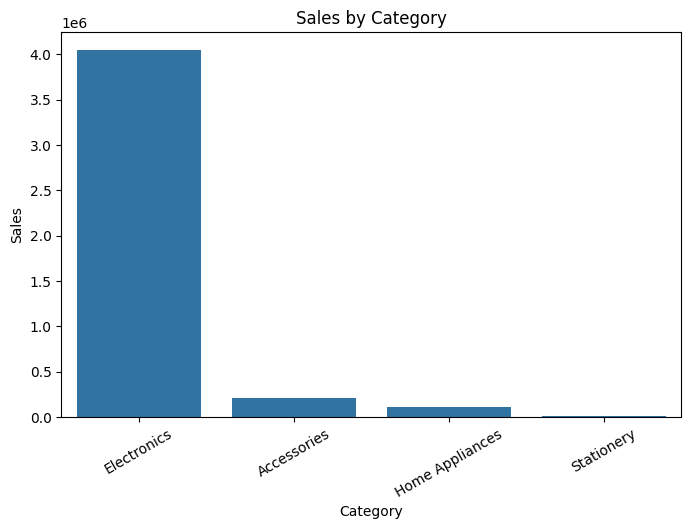

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=30)
plt.show()

In [ ]:
product_sales = (
    df.groupby("Product")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

top_10_products = product_sales.head(10)

print(top_10_products)

Product
Laptop        2090000
Printer        585000
Mobile         575000
Tablet         440000
Monitor        192000
Speaker        160000
Webcam          93000
Iron            70200
Headphones      56000
Mixer           45000
Name: Sales, dtype: int64


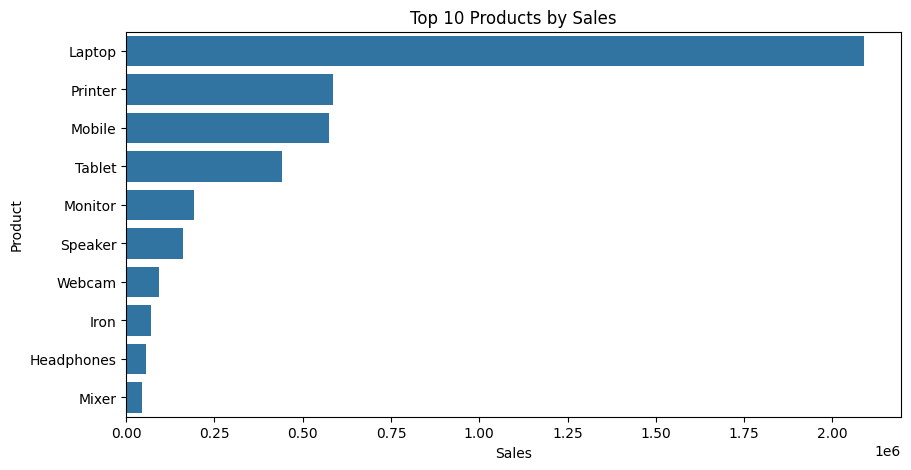

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=top_10_products.values,
    y=top_10_products.index
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()

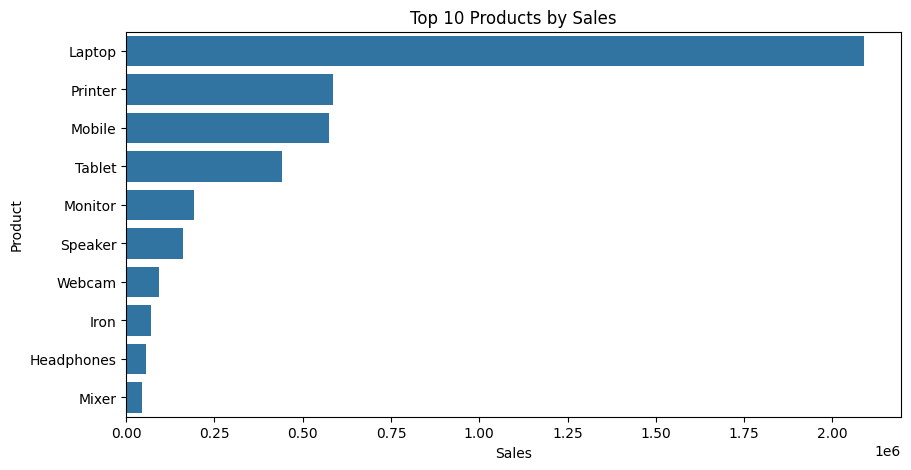

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=top_10_products.values,
    y=top_10_products.index
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=city_sales.index,
    y=city_sales.values
)

plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Sales")
plt.xticks(rotation=30)
plt.show()

NameError: name 'city_sales' is not defined

<Figure size 800x500 with 0 Axes>

City-wise Sales:
City
Nashik        1208980
Aurangabad    1028000
Pune           785040
Nagpur         735780
Mumbai         628300
Name: Sales, dtype: int64


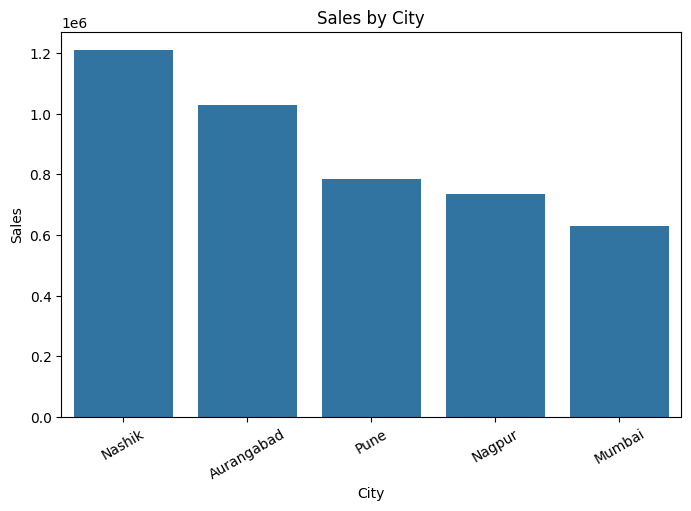

In [ ]:
# City-wise Sales

city_sales = (
    df.groupby("City")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("City-wise Sales:")
print(city_sales)

# Chart
plt.figure(figsize=(8,5))

sns.barplot(
    x=city_sales.index,
    y=city_sales.values
)

plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Sales")
plt.xticks(rotation=30)
plt.show()

In [ ]:
df["Month"] = df["Order_Date"].dt.to_period("M").astype(str)

monthly_sales = (
    df.groupby("Month")["Sales"]
    .sum()
)

print(monthly_sales)

Month
2026-01     757520
2026-02     775520
2026-03     499740
2026-04     236140
2026-05    1386420
2026-06     730760
Name: Sales, dtype: int64


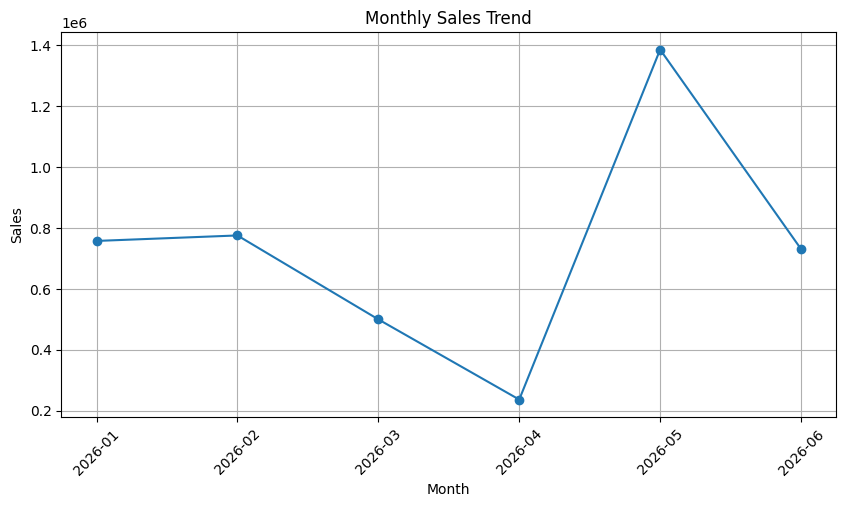

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
# Customer-wise Sales Analysis

customer_sales = (
    df.groupby(["Customer_ID", "Customer_Name"])["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("Top Customers by Sales:")
print(customer_sales.head(10))

Top Customers by Sales:
Customer_ID  Customer_Name  
CUST019      Kunal More         785500
CUST001      Aarav Sharma       468100
CUST012      Snehal More        455680
CUST005      Aditya Deshmukh    296900
CUST002      Priya Patil        295000
CUST008      Pooja Pawar        283160
CUST009      Sanket Jadhav      282900
CUST014      Anjali Thakur      278300
CUST020      Mansi Shah         217120
CUST003      Rahul Joshi        199980
Name: Sales, dtype: int64


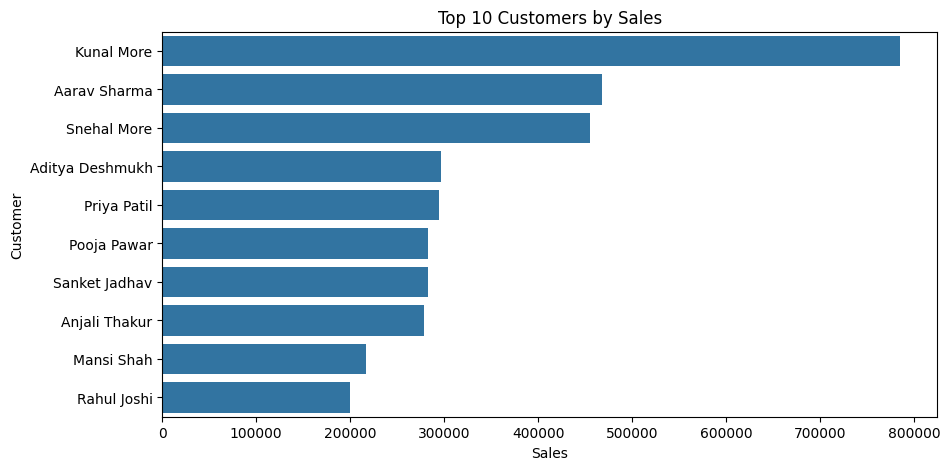

In [ ]:
top_10_customers = customer_sales.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_10_customers.values,
    y=top_10_customers.index.get_level_values("Customer_Name")
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.ylabel("Customer")
plt.show()

In [ ]:
# Count orders for each customer
customer_orders = (
    df.groupby("Customer_ID")["Order_ID"]
    .nunique()
)

# Classify customers
customer_type = customer_orders.apply(
    lambda x: "Repeat Customer" if x > 1 else "New Customer"
)

# Count New vs Repeat Customers
customer_type_counts = customer_type.value_counts()

print("New vs Repeat Customers:")
print(customer_type_counts)

New vs Repeat Customers:
Order_ID
Repeat Customer    20
Name: count, dtype: int64


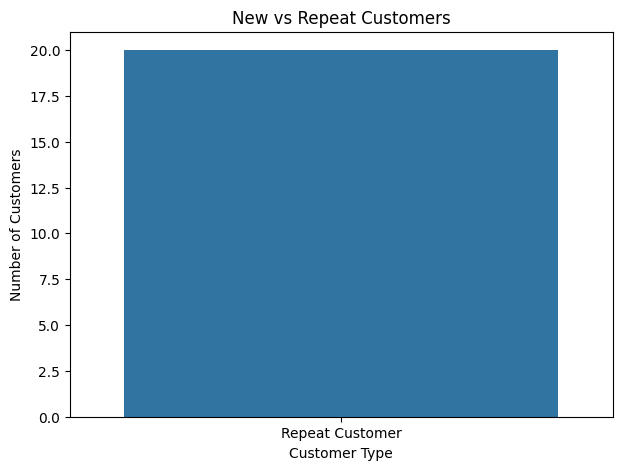

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=customer_type_counts.index,
    y=customer_type_counts.values
)

plt.title("New vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.show()

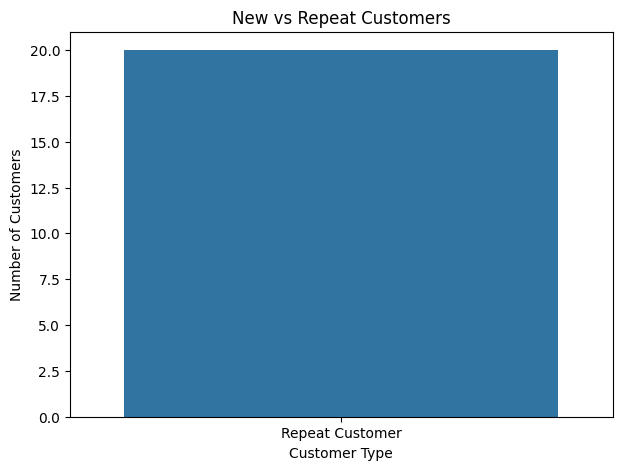

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=customer_type_counts.index,
    y=customer_type_counts.values
)

plt.title("New vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
# RFM Analysis

snapshot_date = df["Order_Date"].max() + pd.Timedelta(days=1)

rfm = df.groupby(["Customer_ID", "Customer_Name"]).agg(
    Recency=("Order_Date", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Order_ID", "nunique"),
    Monetary=("Sales", "sum")
).reset_index()

print(rfm.head(10))

  Customer_ID    Customer_Name  Recency  Frequency  Monetary
0     CUST001     Aarav Sharma        1         11    468100
1     CUST002      Priya Patil       15          9    295000
2     CUST003      Rahul Joshi       16         14    199980
3     CUST004   Sneha Kulkarni       21          9    188380
4     CUST005  Aditya Deshmukh       38          7    296900
5     CUST006        Neha Shah       64          3     15680
6     CUST007       Rohan More       51          9    183520
7     CUST008      Pooja Pawar        2         14    283160
8     CUST009    Sanket Jadhav        4          7    282900
9     CUST010      Kajal Patil       35          3     81500


In [ ]:
# RFM Analysis

snapshot_date = df["Order_Date"].max() + pd.Timedelta(days=1)

rfm = df.groupby(["Customer_ID", "Customer_Name"]).agg(
    Recency=("Order_Date", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Order_ID", "nunique"),
    Monetary=("Sales", "sum")
).reset_index()

print(rfm.head(10))

  Customer_ID    Customer_Name  Recency  Frequency  Monetary
0     CUST001     Aarav Sharma        1         11    468100
1     CUST002      Priya Patil       15          9    295000
2     CUST003      Rahul Joshi       16         14    199980
3     CUST004   Sneha Kulkarni       21          9    188380
4     CUST005  Aditya Deshmukh       38          7    296900
5     CUST006        Neha Shah       64          3     15680
6     CUST007       Rohan More       51          9    183520
7     CUST008      Pooja Pawar        2         14    283160
8     CUST009    Sanket Jadhav        4          7    282900
9     CUST010      Kajal Patil       35          3     81500


In [ ]:
# Create RFM Scores

rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

print(rfm.head(10))

  Customer_ID    Customer_Name  Recency  Frequency  Monetary  R_Score  \
0     CUST001     Aarav Sharma        1         11    468100        5   
1     CUST002      Priya Patil       15          9    295000        4   
2     CUST003      Rahul Joshi       16         14    199980        3   
3     CUST004   Sneha Kulkarni       21          9    188380        3   
4     CUST005  Aditya Deshmukh       38          7    296900        2   
5     CUST006        Neha Shah       64          3     15680        1   
6     CUST007       Rohan More       51          9    183520        1   
7     CUST008      Pooja Pawar        2         14    283160        5   
8     CUST009    Sanket Jadhav        4          7    282900        4   
9     CUST010      Kajal Patil       35          3     81500        2   

   F_Score  M_Score RFM_Score  
0        4        5       545  
1        4        4       444  
2        5        3       353  
3        4        3       343  
4        3        5       235  
5   

In [ ]:
# Create RFM Scores

rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

print(rfm.head(10))

  Customer_ID    Customer_Name  Recency  Frequency  Monetary  R_Score  \
0     CUST001     Aarav Sharma        1         11    468100        5   
1     CUST002      Priya Patil       15          9    295000        4   
2     CUST003      Rahul Joshi       16         14    199980        3   
3     CUST004   Sneha Kulkarni       21          9    188380        3   
4     CUST005  Aditya Deshmukh       38          7    296900        2   
5     CUST006        Neha Shah       64          3     15680        1   
6     CUST007       Rohan More       51          9    183520        1   
7     CUST008      Pooja Pawar        2         14    283160        5   
8     CUST009    Sanket Jadhav        4          7    282900        4   
9     CUST010      Kajal Patil       35          3     81500        2   

   F_Score  M_Score RFM_Score  
0        4        5       545  
1        4        4       444  
2        5        3       353  
3        4        3       343  
4        3        5       235  
5   

In [ ]:
def customer_segment(row):
    if row["R_Score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "Champions"
    elif row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "Loyal Customers"
    elif row["R_Score"] >= 4:
        return "Recent Customers"
    elif row["R_Score"] <= 2 and row["M_Score"] >= 4:
        return "At Risk"
    else:
        return "Potential Customers"

rfm["Segment"] = rfm.apply(customer_segment, axis=1)

print(rfm[[
    "Customer_ID",
    "Customer_Name",
    "Recency",
    "Frequency",
    "Monetary",
    "RFM_Score",
    "Segment"
]].sort_values("Monetary", ascending=False))

   Customer_ID    Customer_Name  Recency  Frequency  Monetary RFM_Score  \
18     CUST019       Kunal More        7         11    785500       455   
0      CUST001     Aarav Sharma        1         11    468100       545   
11     CUST012      Snehal More        1         14    455680       555   
4      CUST005  Aditya Deshmukh       38          7    296900       235   
1      CUST002      Priya Patil       15          9    295000       444   
7      CUST008      Pooja Pawar        2         14    283160       554   
8      CUST009    Sanket Jadhav        4          7    282900       434   
13     CUST014    Anjali Thakur       36          5    278300       224   
19     CUST020       Mansi Shah        2          6    217120       533   
2      CUST003      Rahul Joshi       16         14    199980       353   
3      CUST004   Sneha Kulkarni       21          9    188380       343   
6      CUST007       Rohan More       51          9    183520       143   
15     CUST016     Nikita

Segment
Potential Customers    10
Champions               5
Recent Customers        3
At Risk                 2
Name: count, dtype: int64


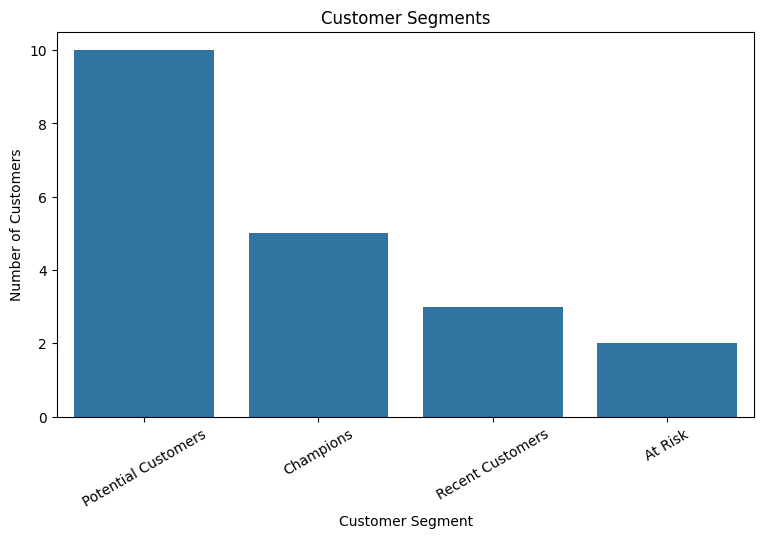

In [ ]:
segment_counts = rfm["Segment"].value_counts()

print(segment_counts)

plt.figure(figsize=(9,5))

sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values
)

plt.title("Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.show()

In [ ]:
top_customers = (
    rfm[["Customer_Name", "Monetary", "Frequency", "Recency", "Segment"]]
    .sort_values("Monetary", ascending=False)
    .head(10)
)

print("Top 10 Customers by Monetary Value:")
print(top_customers)

Top 10 Customers by Monetary Value:
      Customer_Name  Monetary  Frequency  Recency              Segment
18       Kunal More    785500         11        7            Champions
0      Aarav Sharma    468100         11        1            Champions
11      Snehal More    455680         14        1            Champions
4   Aditya Deshmukh    296900          7       38              At Risk
1       Priya Patil    295000          9       15            Champions
7       Pooja Pawar    283160         14        2            Champions
8     Sanket Jadhav    282900          7        4     Recent Customers
13    Anjali Thakur    278300          5       36              At Risk
19       Mansi Shah    217120          6        2     Recent Customers
2       Rahul Joshi    199980         14       16  Potential Customers


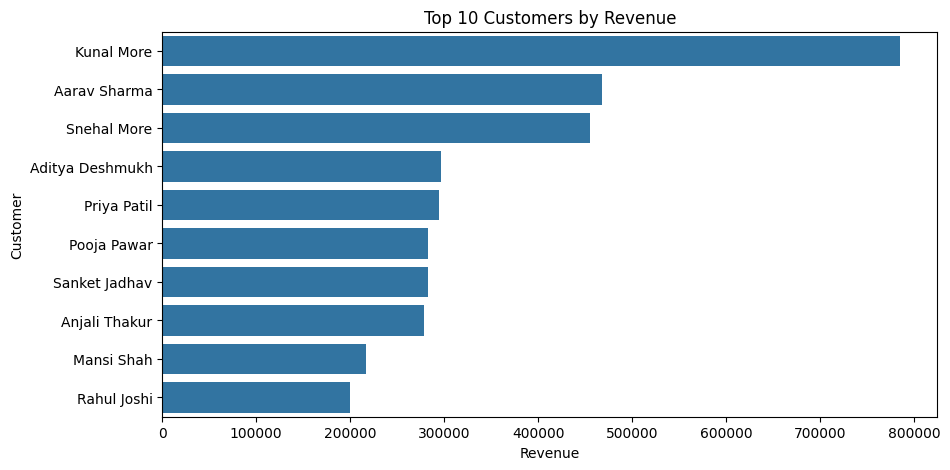

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_customers["Monetary"],
    y=top_customers["Customer_Name"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer")
plt.show()

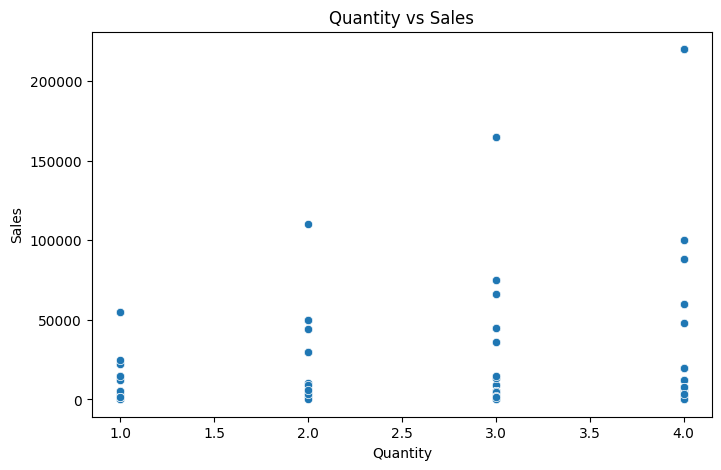

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Sales"
)

plt.title("Quantity vs Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.show()


In [ ]:
correlation = df["Quantity"].corr(df["Sales"])

print("Correlation between Quantity and Sales:", round(correlation, 2))

Correlation between Quantity and Sales: 0.31


In [ ]:
df.to_csv("ecommerce_sales_data.csv", index=False)

print("Dataset saved successfully as ecommerce_sales_data.csv")

Dataset saved successfully as ecommerce_sales_data.csv


In [ ]:
rfm.to_csv("customer_rfm_analysis.csv", index=False)

print("RFM analysis saved successfully.")

RFM analysis saved successfully.


In [ ]:
df.to_csv("ecommerce_sales_data.csv", index=False)

rfm.to_csv("customer_rfm_analysis.csv", index=False)

print("Both files saved successfully!")

Both files saved successfully!


In [ ]:
df.to_csv("/content/ecommerce_sales_data.csv", index=False)
rfm.to_csv("/content/customer_rfm_analysis.csv", index=False)

print("Files saved successfully!")

Files saved successfully!


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'ecommerce_sales_data.csv', 'customer_rfm_analysis.csv', 'sample_data']
